In [16]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import os

print("=== Dataset Structure Summary ===")

# Enhanced: Loops through directories but only prints the folder names and file counts
# instead of flooding your screen with tens of thousands of individual image lines.
for dirname, dirnames, filenames in os.walk('/kaggle/input'):
    # Filter out hidden system files if any exist
    visible_files = [f for f in filenames if not f.startswith('.')]
    
    if visible_files:
        print(f"📁 {dirname}")
        print(f"   └── Contains {len(visible_files)} files\n")

=== Dataset Structure Summary ===
📁 /kaggle/input/datasets/filippopelosi/lunar-surface-dataset
   └── Contains 1 files

📁 /kaggle/input/datasets/filippopelosi/lunar-surface-dataset/Distorted images/368x368
   └── Contains 9500 files

📁 /kaggle/input/datasets/filippopelosi/lunar-surface-dataset/Distorted images/92x92
   └── Contains 9500 files

📁 /kaggle/input/datasets/filippopelosi/lunar-surface-dataset/Distortion-free images/368x368
   └── Contains 9500 files

📁 /kaggle/input/datasets/filippopelosi/lunar-surface-dataset/Distortion-free images/92x92
   └── Contains 9500 files

📁 /kaggle/input/datasets/filippopelosi/lunar-surface-dataset/Distortion-free images/720x480
   └── Contains 9500 files



**Cell 1 – Imports**

In [17]:
import numpy as np
import pandas as pd
import os
import gc

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader
from pathlib import Path
from PIL import Image

import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from tqdm import tqdm

**Cell 2 – Clear GPU**

In [18]:
gc.collect()
torch.cuda.empty_cache()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Running on:", device)

Running on: cuda


**Cell 3 – Dataset**

In [19]:
from torch.utils.data import Dataset
from pathlib import Path
from PIL import Image
import torchvision.transforms as transforms

class LunarDataset(Dataset):
    def __init__(self, distorted_dir, clean_dir):
        self.distorted_dir = Path(distorted_dir)
        self.clean_dir = Path(clean_dir)

        self.image_names = sorted([
            img.name
            for img in self.distorted_dir.glob("*")
            if img.suffix.lower() in [".jpg", ".jpeg", ".png"]
        ])

        self.transform = transforms.Compose([
            transforms.ToTensor()
        ])

    def __len__(self):
        return len(self.image_names)

    def __getitem__(self, idx):
        image_name = self.image_names[idx]

        distorted = Image.open(
            self.distorted_dir / image_name
        ).convert("RGB")

        clean = Image.open(
            self.clean_dir / image_name
        ).convert("RGB")

        distorted = self.transform(distorted)
        clean = self.transform(clean)

        return distorted, clean

**Cell 4 – DataLoader**

In [20]:
distorted_path = "/kaggle/input/datasets/filippopelosi/lunar-surface-dataset/Distorted images/368x368"
clean_path = "/kaggle/input/datasets/filippopelosi/lunar-surface-dataset/Distortion-free images/368x368"

train_dataset = LunarDataset(
    distorted_dir=distorted_path,
    clean_dir=clean_path
)

train_loader = DataLoader(
    train_dataset,
    batch_size=8,
    shuffle=True,
    num_workers=2
)

print("Training Images:", len(train_dataset))

Training Images: 9500


**Cell 5A – U-Net**

In [22]:
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1),
            nn.ReLU(inplace=True),

            nn.Conv2d(out_channels, out_channels, 3, padding=1),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.conv(x)

**Cell 5B**

In [23]:
class UNet(nn.Module):

    def __init__(self):
        super().__init__()

        # Encoder
        self.down1 = DoubleConv(3,64)
        self.pool1 = nn.MaxPool2d(2)

        self.down2 = DoubleConv(64,128)
        self.pool2 = nn.MaxPool2d(2)

        # Bottleneck
        self.middle = DoubleConv(128,256)

        # Decoder
        self.up1 = nn.ConvTranspose2d(256,128,2,stride=2)
        self.conv1 = DoubleConv(256,128)

        self.up2 = nn.ConvTranspose2d(128,64,2,stride=2)
        self.conv2 = DoubleConv(128,64)

        self.final = nn.Conv2d(64,3,1)

    def forward(self,x):

        x1 = self.down1(x)
        x2 = self.down2(self.pool1(x1))

        x3 = self.middle(self.pool2(x2))

        x = self.up1(x3)
        x = torch.cat([x,x2],dim=1)
        x = self.conv1(x)

        x = self.up2(x)
        x = torch.cat([x,x1],dim=1)
        x = self.conv2(x)

        return torch.sigmoid(self.final(x))

**Cell 6**

In [24]:
# ==========================================================
# Stage 4A - U-Net with L1 Loss
# Research Hypothesis:
# Replacing MSE with L1 Loss will produce sharper lunar image
# reconstructions while keeping the architecture unchanged.
# ==========================================================

# Initialize U-Net model
model = UNet().to(device)

# Stage 4A Loss Function
criterion = nn.L1Loss()

# Optimizer (kept identical to Stage 3)
optimizer = optim.Adam(
    model.parameters(),
    lr=0.0005
)

print("=" * 60)
print("Stage 4A Configuration")
print("=" * 60)
print(f"Model        : U-Net")
print(f"Loss Function: L1 Loss (Mean Absolute Error)")
print(f"Optimizer    : Adam")
print(f"Learning Rate: 0.0005")
print("=" * 60)

print(model)

Stage 4A Configuration
Model        : U-Net
Loss Function: L1 Loss (Mean Absolute Error)
Optimizer    : Adam
Learning Rate: 0.0005
UNet(
  (down1): DoubleConv(
    (conv): Sequential(
      (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU(inplace=True)
    )
  )
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (down2): DoubleConv(
    (conv): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU(inplace=True)
    )
  )
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (middle): DoubleConv(
    (conv): Sequential(
      (0): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inpl

**Cell 7**

In [25]:
# Store training loss for plotting
train_losses = []

epochs = 10

print("\nStarting Stage 4A Training...\n")

for epoch in range(epochs):

    model.train()

    running_loss = 0.0

    progress = tqdm(train_loader)

    for distorted, clean in progress:

        distorted = distorted.to(device)
        clean = clean.to(device)

        prediction = model(distorted)

        loss = criterion(prediction, clean)

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        progress.set_description(f"Epoch {epoch+1}/{epochs}")
        progress.set_postfix(loss=f"{loss.item():.5f}")

    epoch_loss = running_loss / len(train_loader)

    train_losses.append(epoch_loss)

    print(f"Epoch [{epoch+1}/{epochs}] Average Loss: {epoch_loss:.5f}")

print("\nStage 4A Training Completed!")
print(f"Final Training Loss: {train_losses[-1]:.5f}")


Starting Stage 4A Training...



Epoch 1/10: 100%|██████████| 1188/1188 [12:03<00:00,  1.64it/s, loss=0.03384]


Epoch [1/10] Average Loss: 0.05427


Epoch 2/10: 100%|██████████| 1188/1188 [12:02<00:00,  1.64it/s, loss=0.05963]


Epoch [2/10] Average Loss: 0.04789


...

Epoch [8/10] Average Loss: 0.04194


Epoch 9/10: 100%|██████████| 1188/1188 [12:01<00:00,  1.65it/s, loss=0.04260]


Epoch [9/10] Average Loss: 0.04146


Epoch 10/10: 100%|██████████| 1188/1188 [12:01<00:00,  1.65it/s, loss=0.03806]

Epoch [10/10] Average Loss: 0.04102

Stage 4A Training Completed!
Final Training Loss: 0.04102


**Cell 8**

In [26]:
torch.save(
    model.state_dict(),
    "lunavision_stage4A_l1.pth"
)

print("Stage 4A model saved successfully!")

Stage 4A model saved successfully!


**Cell 9**

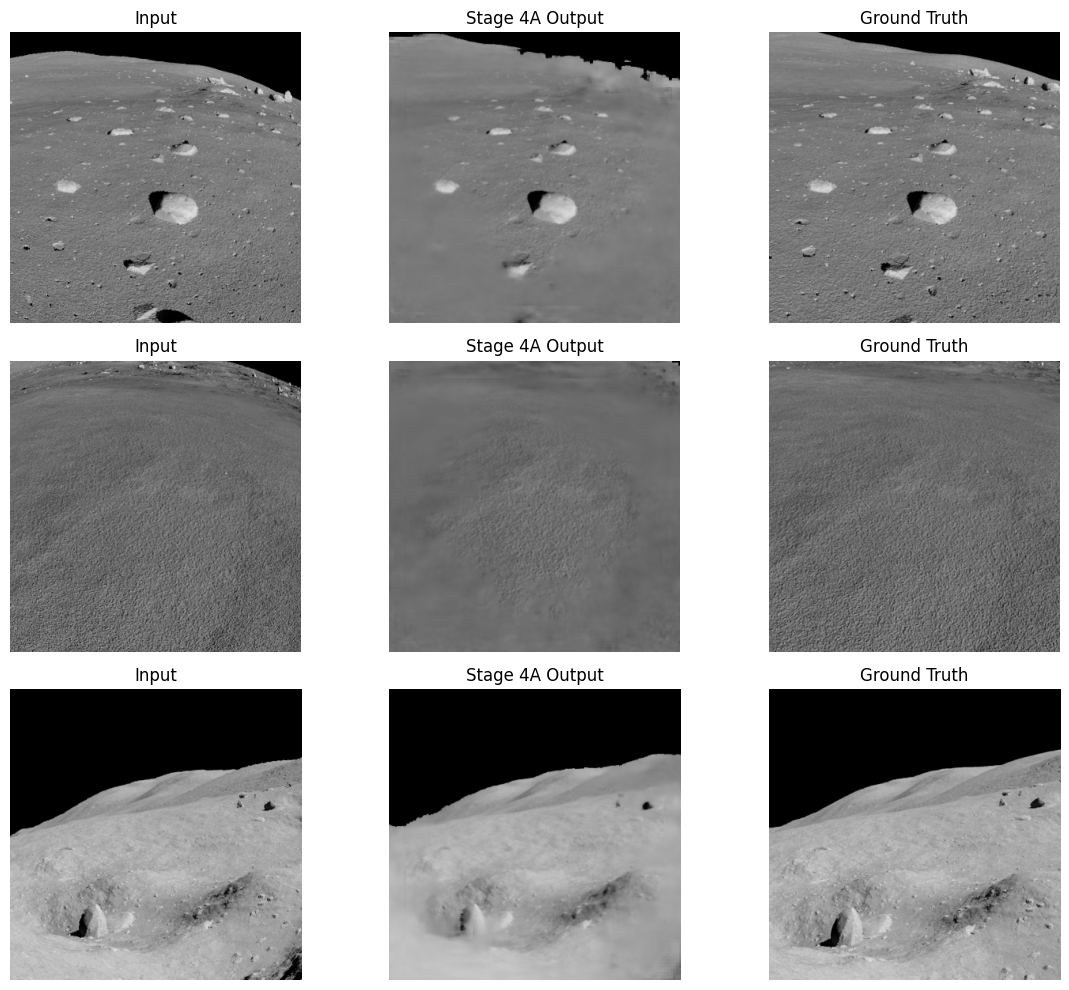

In [27]:
model.eval()

distorted_batch, clean_batch = next(iter(train_loader))

with torch.no_grad():

    prediction = model(
        distorted_batch.to(device)
    ).cpu()

fig, axes = plt.subplots(3, 3, figsize=(12,10))

for i in range(3):

    axes[i,0].imshow(distorted_batch[i].permute(1,2,0))
    axes[i,0].set_title("Input")
    axes[i,0].axis("off")

    axes[i,1].imshow(prediction[i].permute(1,2,0))
    axes[i,1].set_title("Stage 4A Output")
    axes[i,1].axis("off")

    axes[i,2].imshow(clean_batch[i].permute(1,2,0))
    axes[i,2].set_title("Ground Truth")
    axes[i,2].axis("off")

plt.tight_layout()
plt.show()

**Cell 10**

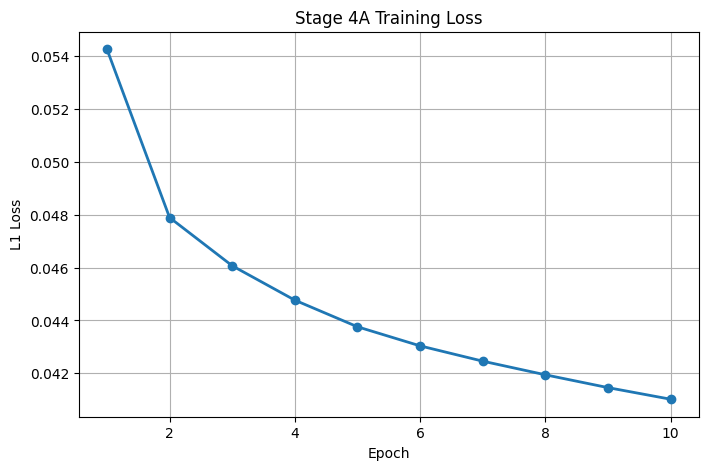

In [28]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1, epochs+1),
    train_losses,
    marker="o",
    linewidth=2
)

plt.title("Stage 4A Training Loss")
plt.xlabel("Epoch")
plt.ylabel("L1 Loss")
plt.grid(True)

plt.show()